In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import Packages
from Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction
from Input_Output_Rxn_Networks.CRNGenerator import CRNGenerator
from Input_Output_Rxn_Networks.ParameterSequenceGenerator import map_index_to_parameter
from Input_Output_Rxn_Networks.ReactionSequenceGenerator import map_indices_to_reactions
import torch
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import types
import time
import multiprocessing as mp
from pathos.multiprocessing import ProcessingPool as Pool
import warnings
warnings.filterwarnings("ignore")

import multiprocess.context as ctx
ctx._force_start_method('fork')

n_threads = mp.cpu_count()

In [3]:
# Select Device
device = torch.device("cuda" if 
torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# Hyperparameters
N_grid = 100                            # Number of grid points for the parameter range
N_samples = 128*5                       # Number of samples to generate for Monte Carlo estimations
entropy_weight = 0.50                   # Initial Entropy weight for the loss function
entropy_update_coefficient = 1.         # Coefficient for updating the entropy weight
entropy_schedule = 100                  # Number of epochs before updating the entropy weight
minimum_entropy_weight = 0.0            # Minimum entropy weight
num_epochs = 5000                       # Number of epochs to train the model
learning_rate = 1e-5                    # Learning rate for the optimizer   
t_final = 100                           # Final time for the simulation

Inputs: ['u']
Species: ['X_1', 'X_2', 'Z_1', 'Z_2']
Output Species: ['X_2']
Reaction 1: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0
Reaction 2: X_1 -> X_1 + X_2 ; Rate Constant: 1.0
Reaction 3: X_1 -> 0 ; Rate Constant: 1.0
Reaction 4: X_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 5: 0 -> Z_1 ; Rate Constant: 10.0u
Reaction 6: X_2 -> X_2 + Z_2 ; Rate Constant: 1.0
Reaction 7: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612
Simulation Time: 0.02
7.463043817800554


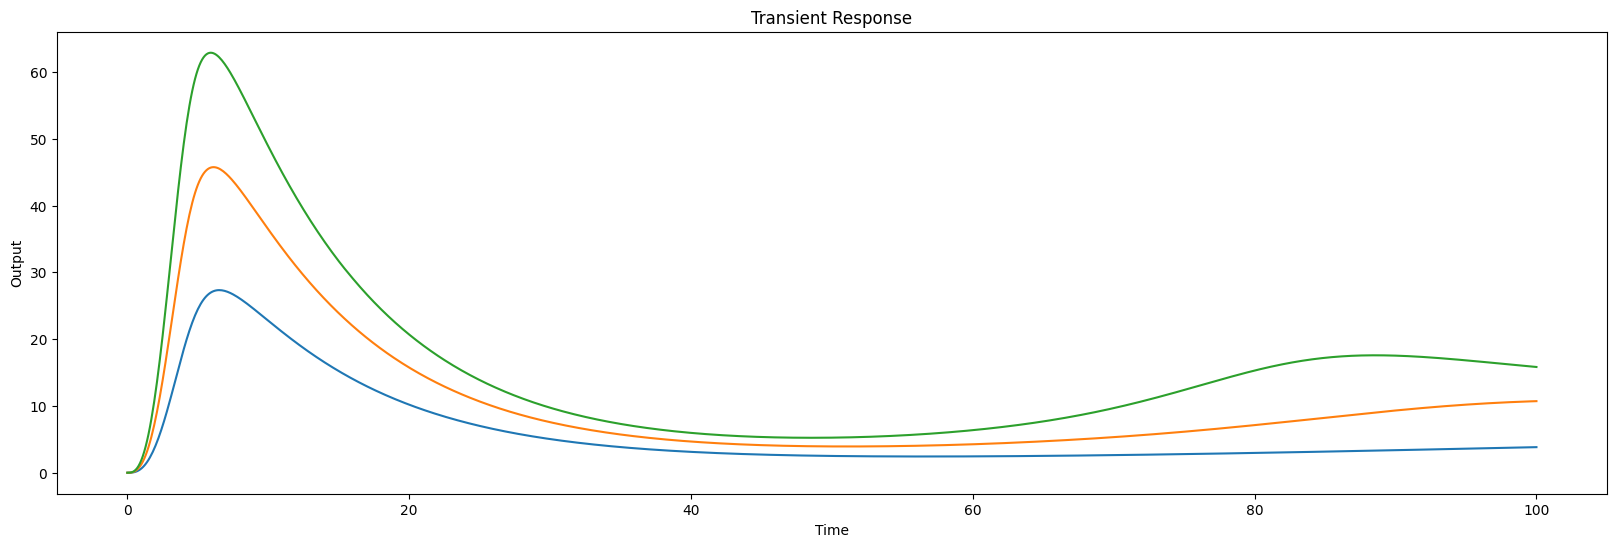

In [5]:
# Construct an IOCRN modeling a Gene Expression process controlled by the AIF controller
stoichiometry_reactants = np.array([[0, 1, 1, 0, 0, 0, 0], [0, 0, 0, 1, 0, 1, 0], [1, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 1]], dtype=np.int8)
stoichiometry_products = np.array([[1, 1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0]], dtype=np.int8)
k = 1; k_1 = 1; gamma_1 = 1; gamma_2 = 0.1; mu = 10; theta = 1; eta = 0.1
parameters = np.array([k, k_1, gamma_1, gamma_2, mu, theta, eta], dtype=np.float32)
input_influence_matrix = np.array([[0, 0, 0, 0, 1, 0, 0]], dtype=np.int8)
outputs = np.array([2], dtype=np.int8)
IOCRN_AIF = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, parameters, input_influence_matrix, outputs)
species = ['X_1', 'X_2', 'Z_1', 'Z_2']
inputs = ['u']
IOCRN_AIF.print_reactions(species, inputs)

# Transient Response for the AIF Controller
u = np.array([[0.5], [1], [1.5]], dtype=np.float32)
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
time_horizon = np.linspace(0, t_final, 1000, dtype=np.float32)

tic = time.time()
outputs_AIF_transient = IOCRN_AIF.transient_response(u, initial_condition, time_horizon)
toc = time.time()
print('Simulation Time: %.2f' % (toc - tic))

plt.figure(figsize=(20, 6))
plt.subplot(1, 1, 1)
for i in range(len(outputs_AIF_transient)):
    plt.plot(time_horizon, outputs_AIF_transient[i])
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response')

print(np.linalg.norm(10 - outputs_AIF_transient[0]) / np.sqrt(len(outputs_AIF_transient[0])))

In [6]:
# Construct the parameter grid
param_1 = np.linspace(0.01, 20, N_grid, dtype=np.float32)
param_2 = np.linspace(0.01, 20, N_grid, dtype=np.float32)
param_3 = np.linspace(0.01, 20, N_grid, dtype=np.float32)
parameter_grid = np.stack([param_1, param_2, param_3], axis=0)

In [7]:
# Construct the CRN Generator
num_species = 4
num_reactions = 2
num_inputs = 1

# Define RSG_Attributes
class RSG_Attributes:
	LSTM_hidden_size = 256
	FFNN_hidden_size = [256, 256, 256]
	FFNN_num_layers = [3, 3, 3]
	weight = [None, None, None]

# Define PSG_Attributes
class PSG_Attributes:
	LSTM_hidden_size = 256
	FFNN_hidden_size = 256
	FFNN_num_layers = 3
	weight = None

MyCRN_Generator = CRNGenerator(num_species, num_reactions, 1, num_inputs, parameter_grid, N_samples, RSG_Attributes, PSG_Attributes).to(device)

In [8]:
# Design the loss function
def Performance_Metric(r, y):
    # return np.linalg.norm(r - y) / np.sqrt(len(y)) # + np.abs(y[-1] - r) 
    y = np.transpose(y, (1, 0, 2))
    weight = np.ones(y.shape[0])
    weight[(len(weight)//10)*9:] = weight[(len(weight)//10)*9:]*2
    weight[:(len(weight)//10)] = weight[:(len(weight)//10)]*0.5
    return (weight*np.abs(r - y)).sum()/ y.shape[0] / y.shape[1] / y.shape[2]

def SS_Metric(r, y_ss):
    return np.abs(r - y_ss)

def unzip(params):
    out = []
    for i in range(len(params[0])):
        out.append([ p[i] for p in params ])
    return out

def _compute_single_loss(args):
    network_outputs, r, initial_condition, time_horizon, CRN_Fixed = args
    stoichiometry_reactants, stoichiometry_products, input_influence_matrix, parameter = network_outputs
    S_R = np.concatenate((CRN_Fixed.stoichiometry_reactants, stoichiometry_reactants), axis=1)
    S_P = np.concatenate((CRN_Fixed.stoichiometry_products, stoichiometry_products),  axis=1)
    S_I = np.concatenate((CRN_Fixed.input_influence_matrix, input_influence_matrix), axis=1)
    
    theta = parameter[-1]
    parameter = np.concatenate((CRN_Fixed.parameters, parameter[:-1]), axis=0)
    parameter[5] = theta

    local_IOCRN = IOCRN_MassAction(S_R, S_P, parameter, S_I, np.array([2], dtype=np.int8))

    # make this line silent
    y, x = local_IOCRN.transient_response(u, initial_condition, time_horizon, return_states=True)
    
    y = np.minimum(y, 1000)
    y = np.maximum(y,0)
    y[np.isnan(y)] = 1000
    y[np.isinf(y)] = 1000
    # y_ss = local_IOCRN.dose_response(inputs, x[-1,:], plot_flag = False, axis=None)

    return Performance_Metric(r, y)



def compute_loss(self, r, initial_condition, time_horizon, h0, c0, manifold_dim, CRN_Fixed):
    network_outputs = self.forward(h0, c0, manifold_dim)
    stoichiometry_reactants, stoichiometry_products, input_influence_matrix, parameter, total_logP, total_entropy, h, c = network_outputs
    network_outputs=stoichiometry_reactants, stoichiometry_products, input_influence_matrix, parameter.T
    network_outputs = unzip(network_outputs)

    # Get maximum number of process workers\
    # n_threads = mp.cpu_count()
    with Pool(n_threads) as pool:
        loss_for_each_sample = pool.map(
            _compute_single_loss,
            [(no, r, initial_condition, time_horizon, CRN_Fixed) for no in network_outputs]
        )

    loss_for_each_sample = torch.tensor(loss_for_each_sample).to(h0)
    loss_mean = torch.mean(loss_for_each_sample)

    return loss_for_each_sample, loss_mean, total_logP, total_entropy

# MyCRN_Generator.Performance_Metric = types.MethodType(Performance_Metric, MyCRN_Generator)
MyCRN_Generator.compute_loss = types.MethodType(compute_loss, MyCRN_Generator)

In [9]:
# Train the CRN generator
r = np.array([[5], [10], [15]], dtype=np.float32)
time_horizon = np.linspace(0, t_final, 100, dtype=np.float32)
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
manifold_dim = 0
h0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
c0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
optimizer = torch.optim.Adam(MyCRN_Generator.parameters(), lr=learning_rate)
tic = time.time()

# Clear the output file
of = open("output.txt", "w")
of.close()

losses = {
    "mean": [],
    "best": [],
    "25p": [],
    "entropy": [],
    "entropy_weight": [],
    "distance": []
}

risky_policy_quantile = 0.25

for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss_for_each_sample, loss_mean, total_logPs, total_entropy = MyCRN_Generator.compute_loss(r, initial_condition, time_horizon, h0, c0, manifold_dim, IOCRN_AIF)
    entropy_mean = torch.mean(total_entropy)

    # Non risky policy gradients
    # loss_for_gradient = torch.mean(loss_for_each_sample.detach() * total_logPs) - entropy_weight * entropy_mean - torch.mean(entropy_weight * total_entropy.detach() * total_logPs)

    # print("MEAN", loss_for_each_sample.mean())

    loss_for_gradient =  (loss_for_each_sample.detach() * total_logPs) - entropy_weight * entropy_mean - (entropy_weight * total_entropy.detach() * total_logPs)
    top_k = torch.topk(loss_for_each_sample - entropy_weight*total_entropy, int(MyCRN_Generator.num_samples * risky_policy_quantile), largest=False).indices
    
    best = loss_for_each_sample[top_k[0]]
    worst = loss_for_each_sample[top_k[-1]]

    loss_for_gradient = torch.mean(loss_for_gradient[top_k])  

    loss_mean = loss_for_each_sample[top_k].mean()

    
    loss_for_gradient.backward()
    optimizer.step()

    percentile_25 = torch.quantile(loss_for_each_sample, 0.25)

    if epoch % 1 == 0:
        of = open("output.txt", "a")
        print('Epoch: %d, Mean Loss: %.4f (real %.4f, best %.4f, .25 %.4f), Entropy: %.4f, Entropy Weight: %.4f' % (epoch, loss_mean.item(), loss_mean.item(), best.item(),  worst.item(), entropy_mean.item(), entropy_weight), file=of)
        of.close()
        losses["distance"].append(loss_mean.item())
        losses["mean"].append(loss_for_gradient.item())
        losses["best"].append(best.item())
        losses["25p"].append(worst.item())
        losses["entropy"].append(entropy_mean.item())
        losses["entropy_weight"].append(entropy_weight)

    if epoch % entropy_schedule == 0 and epoch != 0:
        entropy_weight = max(entropy_weight * entropy_update_coefficient, minimum_entropy_weight)

toc = time.time()
print('Training Time: %.2f' % (toc - tic))

KeyboardInterrupt: 

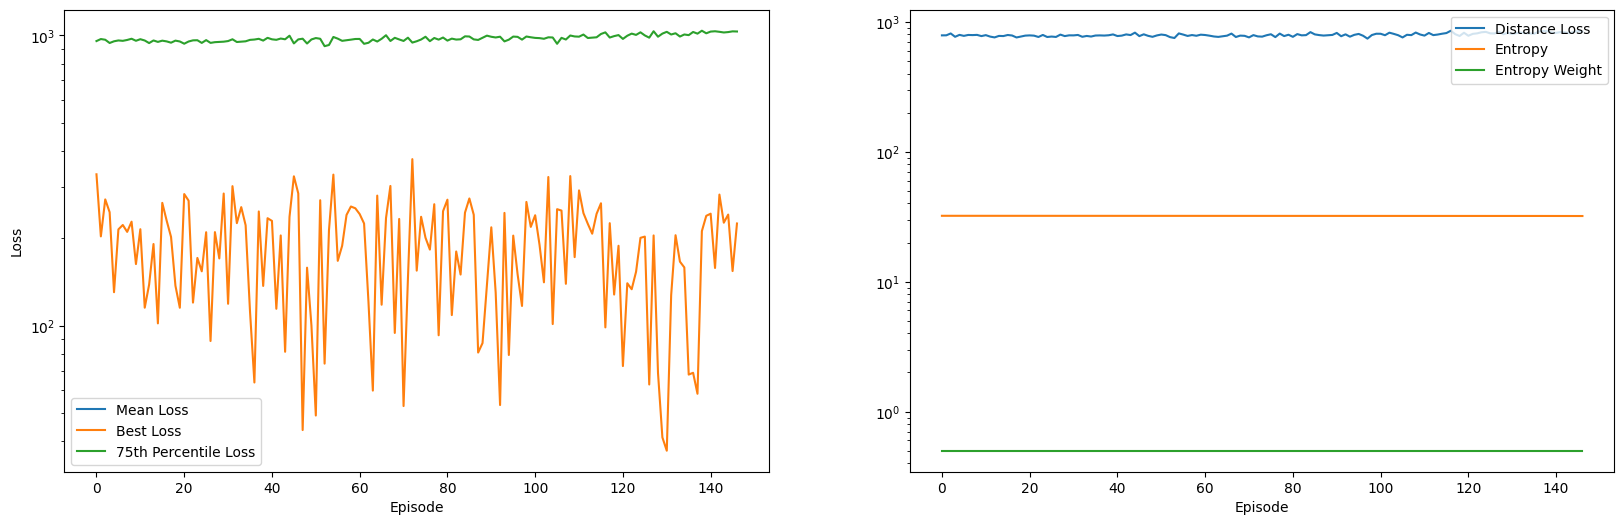

In [10]:
# print all the information about the losses:

plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
plt.plot(losses["mean"], label="Mean Loss")
plt.plot(losses["best"], label="Best Loss")
plt.plot(losses["25p"], label="75th Percentile Loss")
plt.yscale("log")
plt.xlabel("Episode")
plt.ylabel("Loss")

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(losses["distance"], label="Distance Loss")
plt.plot(losses["entropy"], label="Entropy")
plt.plot(losses["entropy_weight"], label="Entropy Weight")
plt.yscale("log")
plt.xlabel("Episode")

plt.legend()


Performance: 58162.0791 best: 174.2773 worst: 558967.8596
Performance: 59392.1922 best: 77.9748 worst: 607509.9194
Performance: 60933.9529 best: 77.9748 worst: 789088.5116
Performance: 62037.9058 best: 69.8987 worst: 789088.5116
Performance: 61726.4976 best: 69.8987 worst: 789088.5116
Performance: 61517.3247 best: 69.8987 worst: 789088.5116
Performance: 61593.1168 best: 69.8987 worst: 789088.5116
Performance: 61328.4879 best: 69.8987 worst: 789088.5116
Performance: 61345.4381 best: 69.8987 worst: 789088.5116
Performance: 61631.8448 best: 69.8987 worst: 789088.5116


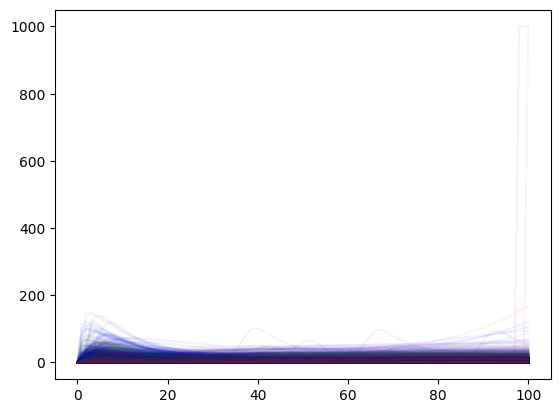

In [55]:
# Test the trained model
n_repeat=10

Performance = []
IOCRN_APIDF2 = []
stoichiometry_reactants = []
stoichiometry_products = []
input_influence_matrix = []
parameter = []

for _ in range(n_repeat):
    h0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
    c0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
    stoichiometry_reactants_, stoichiometry_products_, input_influence_matrix_, parameter_, _, _, _, _= MyCRN_Generator(h0, c0, manifold_dim)

    # Transient Response for the AIF Controller
    u = np.array([[0.5], [1], [1.5]], dtype=np.float32)
    initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
    time_horizon = np.linspace(0, t_final, 100, dtype=np.float32)

    colors = ['r', 'g', 'b']


    for i in range(MyCRN_Generator.num_samples):
        S_R = np.concatenate((IOCRN_AIF.stoichiometry_reactants, stoichiometry_reactants_[i,:,:]), axis=1)
        S_P = np.concatenate((IOCRN_AIF.stoichiometry_products, stoichiometry_products_[i,:,:]),  axis=1)
        S_I = np.concatenate((IOCRN_AIF.input_influence_matrix, input_influence_matrix_[i,:,:]), axis=1)
        p = np.concatenate((IOCRN_AIF.parameters, parameter_[:-1, i]),axis=0)
        p[5] = parameter_[-1, i]
        IOCRN_APIDF2.append(IOCRN_MassAction(S_R, S_P, p, S_I, np.array([2], dtype=np.int8)))
        outputs_transient = IOCRN_APIDF2[-1].transient_response(u, initial_condition, time_horizon)

        

        score = Performance_Metric(r, np.array(outputs_transient))
        Performance.append(score)

        stoichiometry_products.append(stoichiometry_products_[i,:,:])
        stoichiometry_reactants.append(stoichiometry_reactants_[i,:,:])
        input_influence_matrix.append(input_influence_matrix_[i,:,:])
        parameter.append(parameter_[:,i])

        if score<2000.:
            for j in range(len(outputs_transient)):
                plt.plot(time_horizon, outputs_transient[j], alpha=0.05, color=colors[j])


    print('Performance: %.4f' % np.mean(Performance), 'best: %.4f' % np.min(Performance), 'worst: %.4f' % np.max(Performance))


stoichiometry_reactants = np.array(stoichiometry_reactants)
stoichiometry_products = np.array(stoichiometry_products)
input_influence_matrix = np.array(input_influence_matrix)
parameter = np.array(parameter)

# Sort the performance in ascending order
indices = np.argsort(Performance)

(array([1990.,  150.,   60.,   10.,   80.,   60.,   30.,   30.,   90.,
         100.,   70.,   60.,   50.,   60.,  210.,  500.,  950., 1530.,
         160.,   60.,   10.,    0.,   10.,   30.,    0.,   20.,   10.,
          10.,    0.,   10.,   10.,    0.,   10.,    0.,    0.,    0.,
          10.,    0.,    0.,    0.,    0.,    0.,    0.,   10.,    0.,
           0.,    0.,    0.,    0.,   10.]),
 array([7.87207739e+01, 6.01195571e+03, 1.19451907e+04, 1.78784256e+04,
        2.38116605e+04, 2.97448955e+04, 3.56781304e+04, 4.16113653e+04,
        4.75446003e+04, 5.34778352e+04, 5.94110702e+04, 6.53443051e+04,
        7.12775400e+04, 7.72107750e+04, 8.31440099e+04, 8.90772449e+04,
        9.50104798e+04, 1.00943715e+05, 1.06876950e+05, 1.12810185e+05,
        1.18743420e+05, 1.24676654e+05, 1.30609889e+05, 1.36543124e+05,
        1.42476359e+05, 1.48409594e+05, 1.54342829e+05, 1.60276064e+05,
        1.66209299e+05, 1.72142534e+05, 1.78075769e+05, 1.84009004e+05,
        1.89942239e+05, 

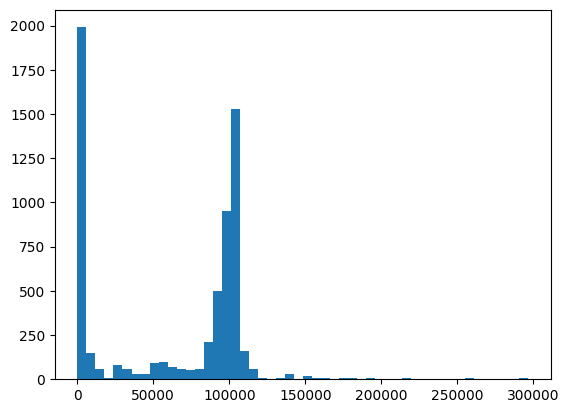

In [38]:
# top 10
plt.hist(Performance, bins=50)

In [39]:
indices[i]

1851

In [40]:
parameter.shape

(6400, 3)

Inputs: ['u']
Species: ['X_1', 'X_2', 'Z_1', 'Z_2']
Output Species: ['X_2']
Reaction 1: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0
Reaction 2: X_1 -> X_1 + X_2 ; Rate Constant: 1.0
Reaction 3: X_1 -> 0 ; Rate Constant: 1.0
Reaction 4: X_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 5: 0 -> Z_1 ; Rate Constant: 10.0u
Reaction 6: X_2 -> X_2 + Z_2 ; Rate Constant: 12.528989791870117
Reaction 7: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 8: Z_1 + Z_2 -> 0 ; Rate Constant: 16.97121238708496
Reaction 9: Z_2 -> Z_1 + Z_2 ; Rate Constant: 15.35585880279541u


Text(0.5, 1.0, 'Transient Response. Score 77.97')

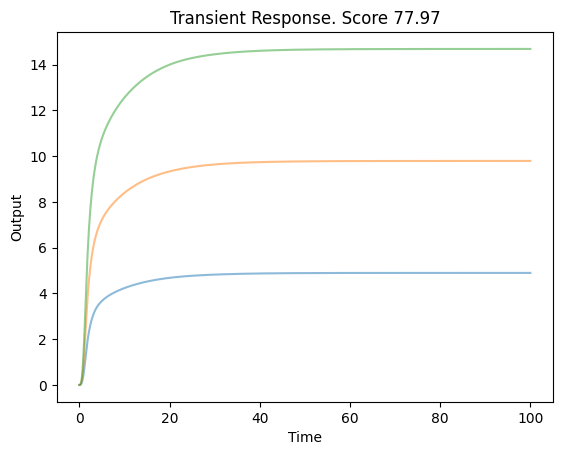

In [76]:
i = indices[1]
IOCRN_APIDF2[i].print_reactions(species, inputs)

u = np.array([[0.5*i+0.5] for i in range(3)], dtype=np.float32)

time_horizon = np.linspace(0, t_final, 1000, dtype=np.float32)

outputs_transient = IOCRN_APIDF2[i].transient_response(u, initial_condition, time_horizon)


for j in range(len(outputs_transient)):
    plt.plot(time_horizon, outputs_transient[j], alpha=0.5)#, color=colors[j])
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response. Score %.2f' % Performance[i])
# plt.legend()

In [14]:
print(p)

[ 1.        1.        1.        0.1      10.       17.778889  0.1
  5.461818 15.557777]


In [15]:
torch.save(MyCRN_Generator.state_dict(), 'WeirdCRN_e5000.pt')

In [16]:
OtherCRN = torch.load('WeirdCRN_e5000.pt')